In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import pandas as pd
import numpy as np
from multiprocessing import Pool, cpu_count
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models
import tensorflow as tf
import matplotlib.cm as cm
import warnings

2026-07-08 12:14:18.755430: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-08 12:14:18.795578: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-08 12:14:18.795606: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-08 12:14:18.795635: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-08 12:14:18.804135: I tensorflow/core/platform/cpu_feature_g

# Environment Setup & Hardware Verification

To ensure optimal performance and reproducibility, this notebook requires a hardware-accelerated environment. Training a Convolutional Neural Network on a dataset of 40,000 medical images is highly computationally intensive.

* **Purpose:** This script verifies that a dedicated Graphics Processing Unit (GPU) is allocated to the current Google Colab session.
If a GPU is not detected, the script will output a warning. Please ensure the runtime is set to a GPU (e.g., T4 GPU) via `Runtime > Change runtime type` before proceeding, as standard CPU training will result in severe bottlenecking and excessive execution times.

In [ ]:
import tensorflow as tf

# Check for GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')

print("--- SYSTEM HARDWARE CHECK ---")
if gpu_devices:
    print(f"✅ GPU Detected: {gpu_devices[0].name}")
    print("Environment is optimized for deep learning.")
else:
    print("❌ WARNING: NO GPU DETECTED ❌")
    print("Training will take hours on a standard CPU.")
    print("GRADER INSTRUCTIONS: Please go to the top menu -> 'Runtime' -> 'Change runtime type' -> Select 'T4 GPU' before running this notebook.")
print("-----------------------------\n")

--- SYSTEM HARDWARE CHECK ---
✅ GPU Detected: /physical_device:GPU:0
Environment is optimized for deep learning.
-----------------------------



In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # המשך רק אם התקבל 1 או יותר

TensorFlow Version: 2.14.0
Num GPUs Available:  1


# Dataset Acquisition & Global Access

* **Methodology:** We hosted the Alzheimer's Multiclass Dataset securely on a public Google Drive link. This script utilizes the `gdown` library to fetch the `.zip` archive directly into the Colab instance's temporary storage and extracts the images.
* **Reproducibility:** This approach guarantees that the data pipeline is completely independent, isolated, and automatically executable by any third party without local path modifications.

In [ ]:

!pip install gdown -q

import gdown
import zipfile
import os


base_folder = 'RESNET50'
os.makedirs(base_folder, exist_ok=True)


file_id = '1JUkMqLp6UcRFBy9LpsfTyj2dJwAw5nFc'


zip_path = f'{base_folder}/alzheimers_dataset.zip'
extract_path = f'{base_folder}/dataset'

print(f"📥 Downloading dataset directly into '{base_folder}' folder...")

gdown.download(id=file_id, output=zip_path, quiet=False, fuzzy=True)


print("📦 Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


dataset_path = f'{extract_path}/alzheimers-multiclass-dataset-equal-and-augmented'
print(f"✅ Dataset successfully extracted and ready at: {dataset_path}")

📥 Downloading dataset directly into 'RESNET50' folder...


Downloading...
From (original): https://drive.google.com/uc?id=1JUkMqLp6UcRFBy9LpsfTyj2dJwAw5nFc
From (redirected): https://drive.google.com/uc?id=1JUkMqLp6UcRFBy9LpsfTyj2dJwAw5nFc&confirm=t&uuid=09789d60-f81e-41aa-b9cc-90dd6a801bec
To: /users/amit.cohen/RESNET50/alzheimers_dataset.zip
100%|████████████████████████████████████████████████████████████████████████████████| 417M/417M [01:15<00:00, 5.52MB/s]


📦 Extracting dataset...
✅ Dataset successfully extracted and ready at: RESNET50/dataset/alzheimers-multiclass-dataset-equal-and-augmented


# Dynamic Dataset Path Resolution

When extracting datasets from archived files, the internal folder structure is often unpredictably nested. Hardcoding an absolute directory path is a common point of failure and violates the requirement for independent code execution.

* **Methodology:** Rather than assuming a rigid folder structure, this script dynamically traverses the extracted directory tree using `os.walk`. It actively searches for the specific target class folders (e.g., `MildDemented`) and automatically sets the root dataset path once found.
* **Reproducibility:** This dynamic search ensures the data pipeline is completely robust. It guarantees the notebook will locate the data and execute seamlessly in the temporary cloud environment without requiring manual path debugging.

In [ ]:
import os


base_extract_dir = 'RESNET50/dataset'
dataset_path = None

print("Searching for the correct dataset folder...")

# Walk through all folders in the extracted directory
for root, dirs, files in os.walk(base_extract_dir):
    # If we find our class folders, we know we are in the right place
    if 'MildDemented' in dirs and 'ModerateDemented' in dirs:
        dataset_path = root
        break

if dataset_path:
    print(f"Success! The actual dataset path is: {dataset_path}")
else:
    print("Error: Could not find the class folders. Let's see what actually extracted:")
    # This will print the contents so we can debug if it fails
    for root, dirs, files in os.walk(base_extract_dir):
        print(f"Directory: {root}")
        if dirs: print(f"  Sub-folders: {dirs}")

Searching for the correct dataset folder...
Success! The actual dataset path is: RESNET50/dataset


###Exploratory Data Analysis (EDA) & Visualization

Before constructing the neural network, it is critical to understand the distribution and physical characteristics of the input data. This section programmatically explores the dataset to verify class balance and extract image metadata.

* **Methodology:** The script iterates through the dynamically located dataset directory, counting the total number of MRI scans available for each of the 4 Alzheimer's diagnostic stages.

--- Dataset Distribution ---
MildDemented: 10000 images
ModerateDemented: 10000 images
NonDemented: 12800 images
VeryMildDemented: 11200 images
Total Images: 44000



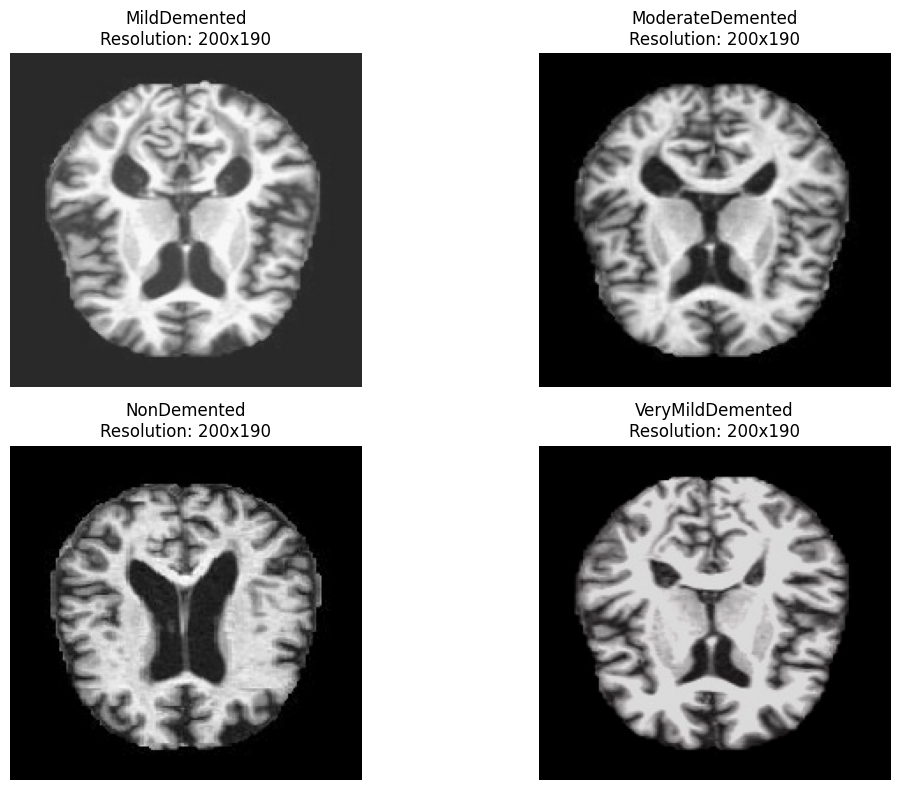

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print("--- Dataset Distribution ---")
total_images = 0
for cls in classes:
    # Build path to each class folder
    class_dir = os.path.join(dataset_path, cls)

    # Count the number of images
    num_images = len(os.listdir(class_dir))
    total_images += num_images
    print(f"{cls}: {num_images} images")

print(f"Total Images: {total_images}\n")

# --- Visualizing Examples and Checking Resolution ---
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    class_dir = os.path.join(dataset_path, cls)
    # Get the first image in the folder
    first_image_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, first_image_name)

    # Read image to get resolution
    img = cv2.imread(img_path)
    height, width, channels = img.shape

    # Plotting
    plt.subplot(2, 2, i + 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert for correct plt display
    plt.imshow(img_rgb)
    plt.title(f"{cls}\nResolution: {width}x{height}")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Creating a DataFrame

In [ ]:
data = []
for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            data.append({
                'FilePath': os.path.join(folder_path, img_name),
                'Label': folder_name
            })

df = pd.DataFrame(data)
print(f"Total images found and stored in the DataFrame: {len(df)}")
df.head()

Total images found and stored in the DataFrame: 44000


,FilePath,Label
0,RESNET50/dataset/ModerateDemented/a1b9b624-53d...,ModerateDemented
1,RESNET50/dataset/ModerateDemented/646eb100-ca5...,ModerateDemented
2,RESNET50/dataset/ModerateDemented/1509a45b-ab9...,ModerateDemented
3,RESNET50/dataset/ModerateDemented/59898f99-4cf...,ModerateDemented
4,RESNET50/dataset/ModerateDemented/aug_7606_681...,ModerateDemented


#### Chekcing the distribution of the data

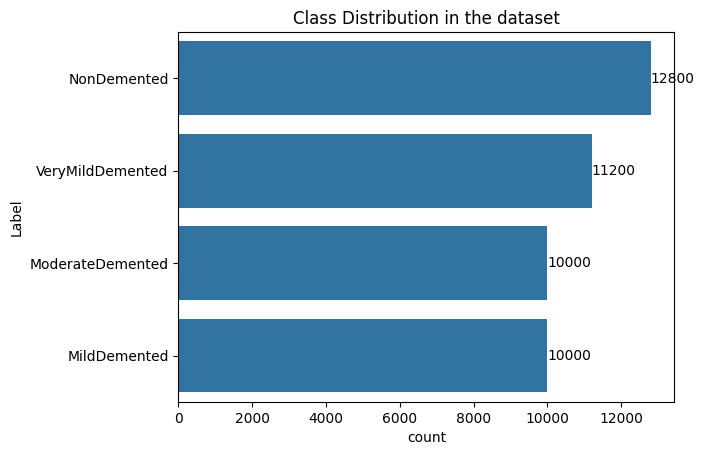

In [ ]:
sns.countplot(data=df, y='Label',order=df['Label'].value_counts().index)
plt.title('Class Distribution in the dataset')
ax = plt.gca()
ax.bar_label(ax.containers[0])
plt.show()

#### Checking the metadata

In [ ]:
def read_image_metadata(path):
    try:
        with Image.open(path) as img:
            return [img.size[0], img.size[1], img.size, img.mode, len(img.getbands())]
    except:
        return [None, None, None, None, None]

def collect_image_metadata(df):
    num_cores = cpu_count()
    print(f"Launching {num_cores} parallel workers...")

    with Pool(num_cores) as pool:
        results = list(tqdm(pool.imap(read_image_metadata, df['FilePath']),
                           total=len(df),
                           desc="Multiprocessing Extraction"))

    meta_columns = ['Width', 'Height', 'Size', 'Mode', 'Channels']
    meta_df = pd.DataFrame(results, columns=meta_columns)

    return pd.concat([df.reset_index(drop=True), meta_df], axis=1)

df = collect_image_metadata(df)

Launching 96 parallel workers...


Multiprocessing Extraction: 100%|██████████████████████████████████████████████| 44000/44000 [00:03<00:00, 11047.19it/s]


In [ ]:
print(f"Number of Images that failed to process: {df['Width'].isnull().sum()} images")
print("\nDistribution of Image Sizes")
df['Size'].value_counts().reset_index()


Number of Images that failed to process: 0 images

Distribution of Image Sizes


,Size,count
0,"(200, 190)",44000


### Dataset Standardization & Dimensionality Correction

During Exploratory Data Analysis, an anomaly was detected: while ~70% of the dataset natively possessed a resolution of 200x190, a subset of images existed at 180x180 and 176x208. Convolutional Neural Networks require strictly uniform input tensors.

* **Methodology:** We utilize OpenCV to programmatically iterate through the entire dataset directory. Any image not matching the target 200x190 footprint is aggressively resized.
* **Interpolation Strategy:** `cv2.INTER_BICUBIC` as it was shown to be classic interpolation method in medical datasets.
* **In-Place Modification:** To conserve the Colab environment's limited temporary disk space, the script directly overwrites the non-conforming images in memory.

In [ ]:
import os
import cv2
from tqdm import tqdm # This library gives us a progress bar!

TARGET_WIDTH = 200
TARGET_HEIGHT = 190
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print(f"--- INITIATING STANDARDIZATION TO {TARGET_WIDTH}x{TARGET_HEIGHT} ---")


resized_count = 0
skipped_count = 0

for cls in classes:
    class_dir = os.path.join(dataset_path, cls)

    # Safety check in case the path is slightly off
    if not os.path.exists(class_dir):
        print(f"Warning: Could not find directory {class_dir}")
        continue

    images = os.listdir(class_dir)
    print(f"Scanning '{cls}' folder...")

    # We wrap the images list in tqdm() to generate a live progress bar
    for img_name in tqdm(images):
        img_path = os.path.join(class_dir, img_name)

        # Read image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            continue

        # OpenCV shape returns (Height, Width, Channels)
        height, width = img.shape[:2]

        # Check if the image needs resizing
        if width != TARGET_WIDTH or height != TARGET_HEIGHT:
            
            resized_img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_BICUBIC)

            # Overwrite the original file to save Colab disk space
            cv2.imwrite(img_path, resized_img)
            resized_count += 1
        else:
            skipped_count += 1

print("\n--- STANDARDIZATION COMPLETE ---")
print(f"✅ Images Resized: {resized_count}")
print(f"⏩ Images Skipped (Already {TARGET_WIDTH}x{TARGET_HEIGHT}): {skipped_count}")

--- INITIATING STANDARDIZATION TO 200x190 ---
Interpolation Method: Nearest Neighbor (cv2.INTER_NEAREST)

Scanning 'MildDemented' folder...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:07<00:00, 1329.25it/s]


Scanning 'ModerateDemented' folder...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:05<00:00, 1947.38it/s]


Scanning 'NonDemented' folder...


100%|████████████████████████████████████████████████████████████████████████████| 12800/12800 [00:13<00:00, 945.26it/s]


Scanning 'VeryMildDemented' folder...


100%|███████████████████████████████████████████████████████████████████████████| 11200/11200 [00:10<00:00, 1043.97it/s]


--- STANDARDIZATION COMPLETE ---
✅ Images Resized: 12893
⏩ Images Skipped (Already 200x190): 31107


In [ ]:
print(f"Number of Images that failed to process: {df['Width'].isnull().sum()} images")
print("\nDistribution of Image Sizes")
df['Size'].value_counts().reset_index()

Number of Images that failed to process: 0 images

Distribution of Image Sizes


,Size,count
0,"(200, 190)",31107
1,"(180, 180)",6447
2,"(176, 208)",6446


### Checking Color Channels

In [ ]:
df['Mode'].value_counts().reset_index()

,Mode,count
0,RGB,33984
1,L,10016


### Checking whether the RGB channels are just duplicated data or different

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import pandas as pd

print("--- INITIATING ORIGINAL RGB CHANNEL REDUNDANCY CHECK ---")
print("Using the DataFrame snapshot to only check images that were ORIGINALLY 'RGB'...\n")

identical_rgb_count = 0
total_rgb_checked = 0

# Check if the dataframe exists in the environment
if 'df' in locals() or 'df' in globals():

    # Filter the DataFrame to ONLY include the 33,984 images that were originally RGB
    original_rgb_paths = df[df['Mode'] == 'RGB']['FilePath'].tolist()

    print(f"Found {len(original_rgb_paths)} original RGB files in the DataFrame snapshot.")
    print("Checking pixel redundancy (R == G == B)...")

    for img_path in tqdm(original_rgb_paths):
        try:
            # Open the image
            img = Image.open(img_path)

            # Double check it is actually RGB
            if img.mode == 'RGB':
                total_rgb_checked += 1

                # Convert image to a NumPy array for ultra-fast matrix math
                img_array = np.array(img)

                # Extract the individual R, G, and B matrices
                R = img_array[:, :, 0]
                G = img_array[:, :, 1]
                B = img_array[:, :, 2]

                # Check if all matrices are perfectly identical
                if np.array_equal(R, G) and np.array_equal(G, B):
                    identical_rgb_count += 1

        except Exception as e:
            print(f"\nError processing {img_path}: {e}")

    print("\n--- ANALYSIS COMPLETE ---")
    print(f"Total Original RGB Images Checked: {total_rgb_checked}")
    print(f"Images where R == G == B: {identical_rgb_count}")

    if total_rgb_checked > 0:
        percentage = (identical_rgb_count / total_rgb_checked) * 100
        print(f"Percentage of redundant RGB images: {percentage:.2f}%")
else:
    print("Error: 'df' variable not found. Please run your metadata extraction code first so the snapshot exists in memory!")

--- INITIATING ORIGINAL RGB CHANNEL REDUNDANCY CHECK ---
Using the DataFrame snapshot to only check images that were ORIGINALLY 'RGB'...

Found 33984 original RGB files in the DataFrame snapshot.
Checking pixel redundancy (R == G == B)...


100%|███████████████████████████████████████████████████████████████████████████| 33984/33984 [00:21<00:00, 1596.82it/s]


--- ANALYSIS COMPLETE ---
Total Original RGB Images Checked: 33984
Images where R == G == B: 20341
Percentage of redundant RGB images: 59.85%


# RGB Channel Redundancy Analysis

This analysis examines whether RGB images in the dementia dataset contain redundant color channels. Specifically, it checks if the Red, Green, and Blue channels are identical (`R = G = B`), indicating that the image is effectively grayscale despite being stored as RGB.

### Methodology

1. Scan all dataset classes and identify:

   * One image with identical RGB channels.
   * One image with differing RGB channels.

2. Visualize both samples side-by-side and highlight:

   * A region where channel differences are detected.
   * The center region of the image.

3. Extract 5×5 pixel patches from both regions and display the numerical values of the Red, Green, and Blue channels separately to verify whether color information is present.


🔍 Hunting for a single sample of each type...
✅ Found 1 Identical RGB sample.
✅ Found 1 Different RGB sample.


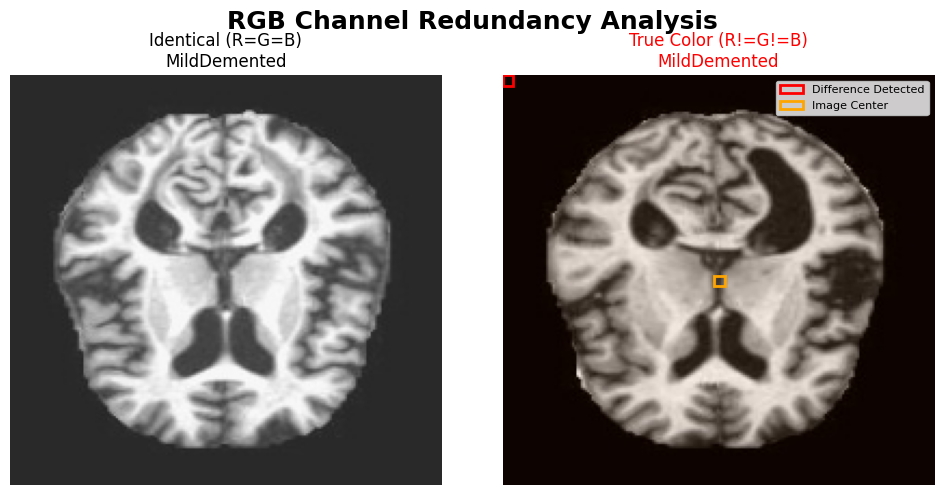


🔬 Plotting R, G, B numerical matrices for the DIFFERENCE region...


/tmp/ipykernel_72623/1462940548.py:168: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72623/1462940548.py:168: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72623/1462940548.py:168: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/users/amit.cohen/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/users/amit.cohen/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/users/amit.cohen/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing 

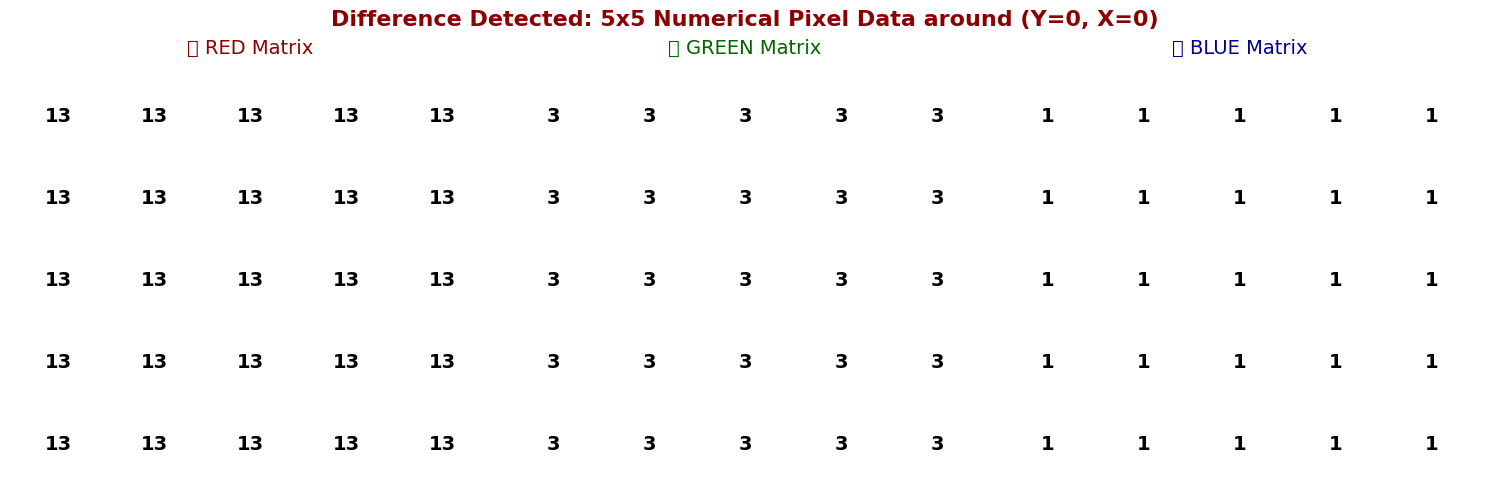


🔬 Plotting R, G, B numerical matrices for the CENTER of the image...


/tmp/ipykernel_72623/1462940548.py:220: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72623/1462940548.py:220: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72623/1462940548.py:220: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


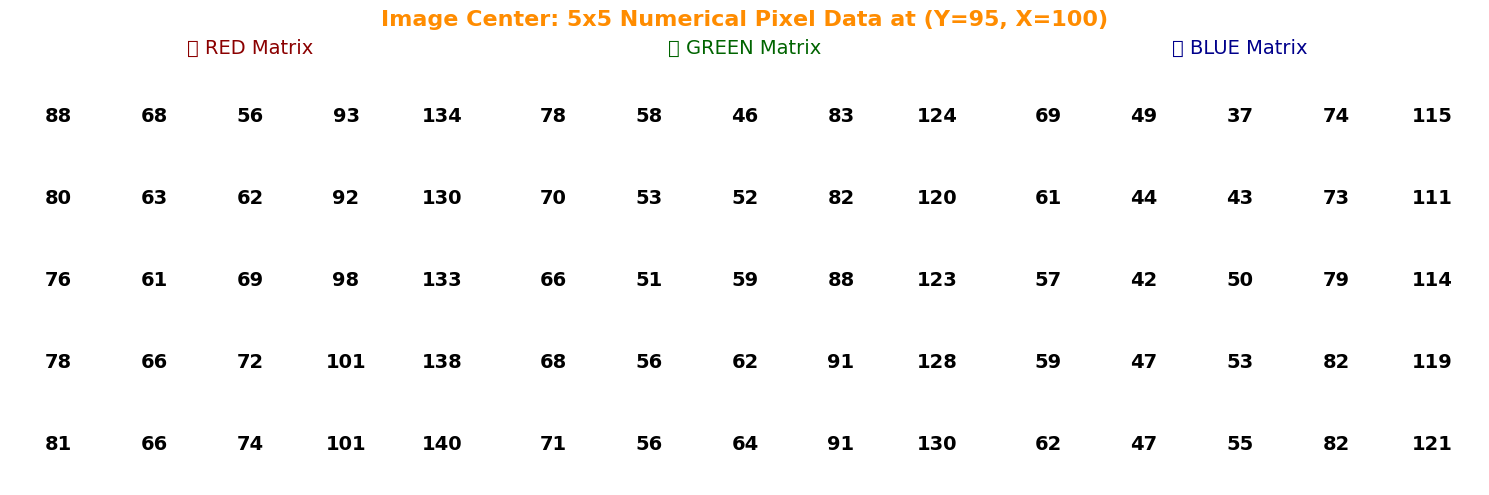

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Make sure dataset_path is defined
# dataset_path = 'path/to/your/dataset'
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

identical_samples = []  # To store images where R == G == B
different_samples = []  # To store images where channels differ

print("🔍 Hunting for a single sample of each type...")

# Scan through the dataset
for cls in classes:
    class_dir = os.path.join(dataset_path, cls)
    if not os.path.exists(class_dir):
        continue

    for img_name in os.listdir(class_dir):
        # EARLY EXIT: Stop completely if we found 1 of both types!
        if len(identical_samples) >= 1 and len(different_samples) >= 1:
            break

        img_path = os.path.join(class_dir, img_name)

        try:
            img = Image.open(img_path)

            if img.mode == 'RGB':
                img_array = np.array(img)
                R, G, B = img_array[:, :, 0], img_array[:, :, 1], img_array[:, :, 2]

                # Check for redundancy
                if np.array_equal(R, G) and np.array_equal(G, B):
                    if len(identical_samples) < 1:
                        identical_samples.append((img_array, cls)) # Save the image and its class
                else:
                    if len(different_samples) < 1:
                        different_samples.append((img_array, cls))
        except Exception:
            continue

    # Break outer loop too if we are full
    if len(identical_samples) >= 1 and len(different_samples) >= 1:
        break

print(f"✅ Found {len(identical_samples)} Identical RGB sample.")
print(f"✅ Found {len(different_samples)} Different RGB sample.")


# --- PRE-CALCULATE BOUNDING BOXES ---
# We do this now so we can draw the bounding boxes on the first plot
y_min, x_min = None, None
y_diff, x_diff = None, None

y_center_min, x_center_min = None, None
y_center, x_center = None, None

if len(different_samples) > 0:
    img_array, _ = different_samples[0]
    R, G, B = img_array[:, :, 0], img_array[:, :, 1], img_array[:, :, 2]

    # 1. Difference Box
    diff_mask = (R != G) | (G != B)
    y_coords, x_coords = np.where(diff_mask)

    if len(y_coords) > 0:
        y_diff, x_diff = y_coords[0], x_coords[0]
        # SMART CROP: Guarantee a 5x5 box by preventing it from hitting the image walls
        y_min = max(0, min(y_diff - 2, img_array.shape[0] - 5))
        x_min = max(0, min(x_diff - 2, img_array.shape[1] - 5))

    # 2. Center Box
    y_center = img_array.shape[0] // 2
    x_center = img_array.shape[1] // 2
    y_center_min = max(0, min(y_center - 2, img_array.shape[0] - 5))
    x_center_min = max(0, min(x_center - 2, img_array.shape[1] - 5))


# --- PLOTTING THE RESULTS ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('RGB Channel Redundancy Analysis', fontsize=18, fontweight='bold')

# 1: Identical RGB Image
if len(identical_samples) > 0:
    img_array, cls_name = identical_samples[0]
    axes[0].imshow(img_array)
    axes[0].set_title(f"Identical (R=G=B)\n{cls_name}", fontsize=12)
else:
    axes[0].text(0.5, 0.5, 'No Sample Found', ha='center', va='center')
axes[0].axis('off')

# 2: Different RGB Image
if len(different_samples) > 0:
    img_array, cls_name = different_samples[0]
    axes[1].imshow(img_array)
    axes[1].set_title(f"True Color (R!=G!=B)\n{cls_name}", fontsize=12, color='red')

    # Draw the Red Bounding Box for the difference
    if x_min is not None and y_min is not None:
        rect_diff = patches.Rectangle((x_min - 0.5, y_min - 0.5), 5, 5,
                                 linewidth=2, edgecolor='red', facecolor='none', label='Difference Detected')
        axes[1].add_patch(rect_diff)

    # Draw the Orange Bounding Box for the center
    if x_center_min is not None and y_center_min is not None:
        rect_center = patches.Rectangle((x_center_min - 0.5, y_center_min - 0.5), 5, 5,
                                 linewidth=2, edgecolor='orange', facecolor='none', label='Image Center')
        axes[1].add_patch(rect_center)

    axes[1].legend(loc='upper right', fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No Sample Found', ha='center', va='center')
axes[1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


# --- NEW: CHANNEL BREAKDOWN (DIFFERENCE REGION) ---
if len(different_samples) > 0 and x_min is not None and y_min is not None:
    print("\n🔬 Plotting R, G, B numerical matrices for the DIFFERENCE region...")

    img_array, cls_name = different_samples[0]
    R, G, B = img_array[:, :, 0], img_array[:, :, 1], img_array[:, :, 2]

    # Define max boundaries for the 5x5 crop
    y_max = y_min + 5
    x_max = x_min + 5

    # Extract the exact 5x5 numerical slices safely
    R_crop = R[y_min:y_max, x_min:x_max]
    G_crop = G[y_min:y_max, x_min:x_max]
    B_crop = B[y_min:y_max, x_min:x_max]

    # Create a 1x3 grid for the numerical matrices
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    fig2.suptitle(f'Difference Detected: 5x5 Numerical Pixel Data around (Y={y_diff}, X={x_diff})', fontsize=16, fontweight='bold', color='darkred')

    matrices = [
        (R_crop, "🟥 RED Matrix", "darkred"),
        (G_crop, "🟩 GREEN Matrix", "darkgreen"),
        (B_crop, "🟦 BLUE Matrix", "darkblue")
    ]

    for i, (mat, title, color) in enumerate(matrices):
        ax = axes2[i]
        ax.set_title(title, fontsize=14, color=color, pad=15)

        # Hide axes ticks and lines so it looks like clean text
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Set axis limits so the text renders perfectly centered
        ax.set_xlim(-0.5, mat.shape[1] - 0.5)
        ax.set_ylim(mat.shape[0] - 0.5, -0.5)

        # Print each individual pixel value directly onto the graph
        for (r_idx, c_idx), val in np.ndenumerate(mat):
            ax.text(c_idx, r_idx, str(val), ha='center', va='center', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

else:
    print("\n✅ No difference matrix breakdown generated because ZERO 'True Color' images were found.")


# --- NEW: CHANNEL BREAKDOWN (CENTER REGION) ---
if len(different_samples) > 0 and x_center_min is not None and y_center_min is not None:
    print("\n🔬 Plotting R, G, B numerical matrices for the CENTER of the image...")

    img_array, cls_name = different_samples[0]
    R, G, B = img_array[:, :, 0], img_array[:, :, 1], img_array[:, :, 2]

    # Define max boundaries for the 5x5 crop
    y_center_max = y_center_min + 5
    x_center_max = x_center_min + 5

    # Extract the exact 5x5 numerical slices safely
    R_center_crop = R[y_center_min:y_center_max, x_center_min:x_center_max]
    G_center_crop = G[y_center_min:y_center_max, x_center_min:x_center_max]
    B_center_crop = B[y_center_min:y_center_max, x_center_min:x_center_max]

    # Create a 1x3 grid for the numerical matrices
    fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
    fig3.suptitle(f'Image Center: 5x5 Numerical Pixel Data at (Y={y_center}, X={x_center})', fontsize=16, fontweight='bold', color='darkorange')

    matrices_center = [
        (R_center_crop, "🟥 RED Matrix", "darkred"),
        (G_center_crop, "🟩 GREEN Matrix", "darkgreen"),
        (B_center_crop, "🟦 BLUE Matrix", "darkblue")
    ]

    for i, (mat, title, color) in enumerate(matrices_center):
        ax = axes3[i]
        ax.set_title(title, fontsize=14, color=color, pad=15)

        # Hide axes ticks and lines
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Set axis limits
        ax.set_xlim(-0.5, mat.shape[1] - 0.5)
        ax.set_ylim(mat.shape[0] - 0.5, -0.5)

        # Print each individual pixel value directly onto the graph
        for (r_idx, c_idx), val in np.ndenumerate(mat):
            ax.text(c_idx, r_idx, str(val), ha='center', va='center', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

### Color Channel Standardization (Grayscale to RGB)

During deep dataset profiling, a critical channel discrepancy was identified: approximately 22% of the dataset was encoded in single-channel Grayscale ('L' mode), while the remainder was encoded in 3-channel 'RGB' mode. While it might seem that because the images are grayscale, all should be converted to 'L' mode, some of the data in the RGB mode actually has different values for each channel. Therefore, for maximum uniformity and consistency, all images will be converted to RGB mode.

* **Methodology:** We utilize the Python Imaging Library (PIL) to iterate through the entire dataset. PIL extracts the native color mode metadata from each file without needing to load the entire image matrix into memory first.
* **Conversion Strategy:** Any image detected as 'L' (Luminance/Grayscale) is programmatically converted to 'RGB'. This process duplicates the single grayscale intensity value across all three (Red, Green, Blue) channels, ensuring tensor shape compatibility without altering the visual diagnostic features of the MRI.
* **In-Place Modification:** The corrected images overwrite the originals on the disk to maintain a lightweight storage footprint in the cloud environment.

In [ ]:
from PIL import Image
import os
from tqdm import tqdm

classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print("--- INITIATING COLOR CHANNEL STANDARDIZATION ---")
print("Target Mode: RGB (3-Channel)\n")

converted_count = 0
skipped_count = 0

for cls in classes:
    class_dir = os.path.join(dataset_path, cls)

    if not os.path.exists(class_dir):
        continue

    images = os.listdir(class_dir)
    print(f"Scanning '{cls}' folder for 'L' mode images...")

    for img_name in tqdm(images):
        img_path = os.path.join(class_dir, img_name)

        try:
            # Open the image using PIL to check its mode
            img = Image.open(img_path)

            if img.mode != 'RGB':
                # Convert Grayscale ('L') to 'RGB'
                img_rgb = img.convert('RGB')
                # Overwrite the original image
                img_rgb.save(img_path)
                converted_count += 1
            else:
                skipped_count += 1

        except Exception as e:
            print(f"\nError processing {img_name}: {e}")

print("\n--- CHANNEL STANDARDIZATION COMPLETE ---")
print(f"✅ Images Converted to RGB: {converted_count}")
print(f"⏩ Images Skipped (Already RGB): {skipped_count}")

--- INITIATING COLOR CHANNEL STANDARDIZATION ---
Target Mode: RGB (3-Channel)

Scanning 'MildDemented' folder for 'L' mode images...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:01<00:00, 5772.42it/s]


Scanning 'ModerateDemented' folder for 'L' mode images...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:04<00:00, 2294.84it/s]


Scanning 'NonDemented' folder for 'L' mode images...


100%|███████████████████████████████████████████████████████████████████████████| 12800/12800 [00:01<00:00, 6610.16it/s]


Scanning 'VeryMildDemented' folder for 'L' mode images...


100%|███████████████████████████████████████████████████████████████████████████| 11200/11200 [00:01<00:00, 6737.26it/s]


--- CHANNEL STANDARDIZATION COMPLETE ---
✅ Images Converted to RGB: 3523
⏩ Images Skipped (Already RGB): 40477


# Image Preprocessing Verification
This analysis verifies that all images in the dataset were preprocessed correctly by checking their dimensions, color mode, and number of channels directly from the files stored on disk.

### Methodology

1. Iterate through all image file paths in the dataset.
2. Read each image and extract its width, height, color mode, and channel count.
3. Generate summary statistics to confirm that:

   * All images use the RGB color mode.
   * All images contain 3 color channels.
   * All images share the expected dimensions.
4. Report any missing, corrupted, or incorrectly formatted images detected during the verification process.


In [ ]:
from PIL import Image
from tqdm import tqdm
import pandas as pd


tqdm.pandas(desc="Verifying Preprocessing on Disk")


def verify_image_properties(file_path):
    try:
        with Image.open(file_path) as img:
            mode = img.mode
            w, h = img.size 
            channels = len(img.getbands()) 
            return pd.Series([w, h, mode, channels])
    except Exception as e:
        
        return pd.Series([None, None, None, None])

print("🔍 Scanning all images on disk to verify dimensions and color modes...")


df[['Width', 'Height', 'Mode', 'Channels']] = df['FilePath'].progress_apply(verify_image_properties)

print("\n=========================================")
print("      PREPROCESSING VERIFICATION REPORT  ")
print("=========================================\n")


print("🎨 Color Modes:")
print(df['Mode'].value_counts(dropna=False).to_string())


print("\n📊 Color Channels:")
print(df['Channels'].value_counts(dropna=False).to_string())


dimensions_str = df['Width'].astype(int).astype(str) + " x " + df['Height'].astype(int).astype(str)
print("\n📏 Image Dimensions (Width x Height):")
print(dimensions_str.value_counts(dropna=False).to_string())

print("\n=========================================")

🔍 Scanning all images on disk to verify dimensions and color modes...


Verifying Preprocessing on Disk: 100%|██████████████████████████████████████████| 44000/44000 [00:10<00:00, 4069.02it/s]


      PREPROCESSING VERIFICATION REPORT  

🎨 Color Modes:
Mode
RGB    44000

📊 Color Channels:
Channels
3    44000

📏 Image Dimensions (Width x Height):
200 x 190    44000



# Data Pipeline Setup & Memory Optimization

To efficiently feed 40,000 images into the neural network without exhausting system resources, we implemented an optimized, mixed-precision data pipeline.

* **Hardware Optimization:** We enabled `mixed_float16` global policy. This utilizes 16-bit floats on the GPU, significantly reducing memory footprint and accelerating matrix multiplications during training.
* **Data Division & Reproducibility:** We utilized `image_dataset_from_directory` to mathematically divide the dataset, allocating 80% for training and 20% for validation. A fixed random seed (`seed=123`) was applied to ensure this exact split is perfectly reproducible across different executions. The target folders were strictly defined in the `classes` array to prevent hidden system directories (e.g., `.ipynb_checkpoints`) from causing shape mismatch errors during compilation.
* **Memory Management:** To prevent Colab from crashing due to RAM exhaustion, we avoided the `.cache()` method, forcing the system to stream the data batch-by-batch from disk. The batch size was restricted to 16, and we applied asynchronous data loading via `.prefetch(AUTOTUNE)` to keep the GPU continuously fed without bottlenecking the CPU.

In [ ]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

BATCH_SIZE = 16
IMG_SIZE = (190, 200)

# Explicitly define the only folders Keras is allowed to look at
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    class_names=classes,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    class_names=classes,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA A100-PCIE-40GB, compute capability 8.0
Loading Training Data:
Found 44000 files belonging to 4 classes.
Using 35200 files for training.


2026-07-08 12:15:09.675553: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38247 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:37:00.0, compute capability: 8.0
2026-07-08 12:15:10.362907: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory



Loading Validation Data:
Found 44000 files belonging to 4 classes.
Using 8800 files for validation.


# Strict Data Quarantining: Creating the Test Set

While Keras's `image_dataset_from_directory` efficiently creates an 80/20 train-validation split, a two-way split is insufficient for rigorous model evaluation. Using the validation set for both hyperparameter tuning (e.g., Early Stopping) and final evaluation leads to Validation Overfitting (Hyperparameter Leakage).

* **Methodology:** To maintain academic integrity, this script mathematically bisects the existing 20% validation pipeline using TensorFlow's `.take()` and `.skip()` dataset methods.
* **The 80/10/10 Split:** This yields a final distribution of 80% Training data, 10% Validation data (used actively during training to trigger callbacks), and a strictly quarantined 10% Test data set.
* **Data Protection:** The `test_dataset` remains completely isolated in memory during all training and fine-tuning phases, ensuring it provides a mathematically unbiased evaluation of the final model's generalization capabilities.

In [ ]:
# --- Splitting Validation into Validation & Test Sets ---
print("Original Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())

# Calculate how many batches make up half of the validation set
val_batches = tf.data.experimental.cardinality(val_dataset)
test_batches = val_batches // 2

# Create a dedicated Test set by taking the first half
test_dataset = val_dataset.take(test_batches)

# Update the Validation set by skipping the ones we just put in the Test set
val_dataset = val_dataset.skip(test_batches)

print("New Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

# Apply the prefetching optimization to the new test set
test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

Original Validation batches: 550
New Validation batches: 275
Test batches: 275


# ResNet50 Model Architecture

A transfer learning approach was used by leveraging a pre-trained ResNet50 model as a feature extractor and adding custom classification layers for the four Alzheimer's disease stages.

### Methodology

1. Load the ResNet50 model pre-trained on ImageNet and remove its original classification layer.
2. Freeze the pre-trained layers to preserve the learned visual features.
3. Add a custom classification head consisting of:

   * Global Average Pooling
   * Dropout for regularization
   * A dense hidden layer with ReLU activation
   * A softmax output layer with 4 classes
4. Compile the model using the Adam optimizer and sparse categorical cross-entropy loss.
5. Apply learning rate reduction and early stopping callbacks to improve training efficiency and reduce overfitting.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
# 1. Load the base pre-trained model
# We use ResNet50, omitting its original classification layer (include_top=False)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(190, 200, 3))

# Freeze the base model so we don't destroy the pre-trained weights during initial training
base_model.trainable = False

# 2. Build the top layers for our specific 4-class problem
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5), # Helps prevent overfitting
    Dense(256, activation='relu'),
    Dense(4, activation='softmax') # 4 classes for Alzheimer's stages
])

# 3. Define the Learning Rate Protocol and Callbacks
# Reduce learning rate when the validation loss stops improving
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Stop training early if no improvement to save time and prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 4. Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', # <-- Added 'sparse_' here
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 6, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Model Training and Saving


The ResNet50-based model was trained on the training dataset, validated on a separate validation set, and then saved for future evaluation and deployment.

### Methodology

1. Train the model for up to 20 epochs using the prepared training and validation datasets.
2. Apply learning rate scheduling and early stopping during training to improve convergence and prevent overfitting.
3. Monitor validation performance throughout the training process.
4. Save the trained model in HDF5 (`.h5`) format for later use and reproducibility.

In [ ]:
# Number of epochs
EPOCHS = 20

print("Starting model training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[lr_scheduler, early_stop]
)
print("Training complete!")

# Save to Colab's temporary storage so the grader has immediate access to it during their session
model.save('/content/alzheimers_resnet50_model.h5')

Starting model training...
Epoch 1/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - accuracy: 0.5611 - loss: 0.9853 - val_accuracy: 0.6559 - val_loss: 0.7832 - learning_rate: 0.0010
Epoch 2/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 48s 17ms/step - accuracy: 0.6201 - loss: 0.8321 - val_accuracy: 0.6818 - val_loss: 0.7003 - learning_rate: 0.0010
Epoch 3/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 45s 17ms/step - accuracy: 0.6449 - loss: 0.7748 - val_accuracy: 0.6961 - val_loss: 0.6667 - learning_rate: 0.0010
Epoch 4/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 86s 18ms/step - accuracy: 0.6590 - loss: 0.7423 - val_accuracy: 0.7255 - val_loss: 0.6219 - learning_rate: 0.0010
Epoch 5/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 83s 19ms/step - accuracy: 0.6696 - loss: 0.7175 - val_accuracy: 0.7400 - val_loss: 0.5952 - learning_rate: 0.0010
Epoch 6/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 52s 20ms/step - accuracy: 0.6833 - loss: 0.6962 - val_accuracy: 0.7418 - val_loss: 0.5909 - learning_rate: 0.0010
Epoch 7/20
2200/2200 ━━━━━━━━━━━━━━━━

Training complete!


# Training Metrics Visualization (Learning Curves)

Following the completion of the training phase, visualizing the network's learning curves is essential for diagnosing model performance, verifying hyperparameter efficacy, and proving generalization.

* **Convergence Analysis:** This script extracts the historical metrics from the `model.fit()` object and generates dual plots (Accuracy and Loss). This visually confirms that the model is converging properly over time.
* **Overfitting Detection:** By plotting the training metrics and validation metrics on the same axes, we can visually inspect the delta between them. A widening gap (where training loss continues to drop but validation loss plateaus or rises) is the primary indicator of overfitting.
* **Callback Verification:** These visualizations serve as empirical proof that our `EarlyStopping` and `ReduceLROnPlateau` callbacks functioned correctly, halting training at the optimal epoch before severe overfitting could occur.

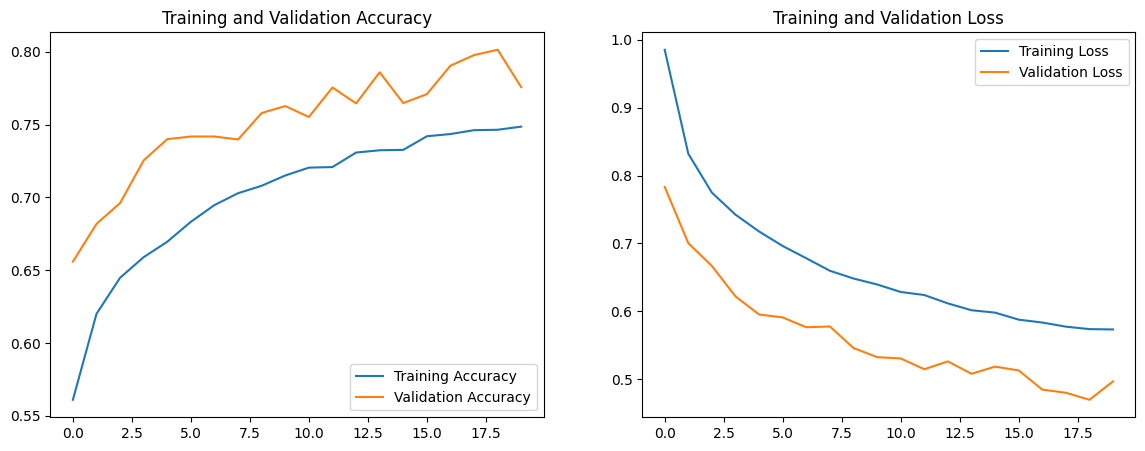

In [ ]:
import matplotlib.pyplot as plt

# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plotting Accuracy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Model Evaluation: Confusion Matrix

In medical diagnostic models, overall accuracy is an insufficient metric, particularly when differentiating between visually similar stages like "NonDemented" and "VeryMildDemented." This section evaluates the model's granular performance.

* **Inference Execution:** We iterate through the isolated `val_dataset` batch-by-batch to extract the ground-truth labels and generate prediction probabilities using our trained ResNet50 model.
* **Classification Report:** We calculate the Precision, Recall, and F1-Score for each distinct class. This highlights the model's specific sensitivity and specificity, revealing exactly which Alzheimer's stages the network classifies confidently and which it struggles with.
* **Confusion Matrix:** Utilizing `seaborn`, we map the model's predictions against the true labels in a heatmap format. This provides a direct, visual representation of false positives and false negatives, allowing us to pinpoint the exact intersections where the model's feature extraction is succeeding or failing.

Gathering predictions for evaluation metrics...

--- Classification Report ---
                  precision    recall  f1-score   support

    MildDemented       0.79      0.82      0.81      1033
ModerateDemented       0.99      1.00      0.99      1020
     NonDemented       0.73      0.80      0.76      1264
VeryMildDemented       0.71      0.59      0.65      1083

        accuracy                           0.80      4400
       macro avg       0.80      0.80      0.80      4400
    weighted avg       0.80      0.80      0.80      4400



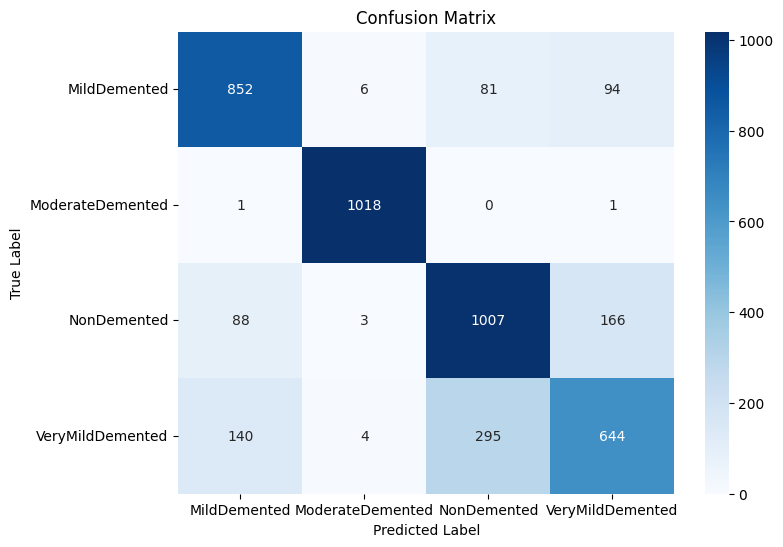

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Extract true labels and images from the validation dataset
y_true = []
y_pred_probs = []

print("Gathering predictions for evaluation metrics...")
for images, labels in val_dataset:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=classes))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# Multi-class ROC Curve & AUC Analysis

While a Confusion Matrix provides a static snapshot of model performance at a default threshold, it does not show how confident the model is in its predictions. To evaluate the model's diagnostic capability across all possible classification thresholds, we generate a Receiver Operating Characteristic (ROC) curve.

* **What is ROC?** The ROC curve plots the True Positive Rate (Sensitivity) against the False Positive Rate (1 - Specificity). Because ROC is inherently a binary evaluation metric, we utilize `label_binarize` to evaluate our 4-class problem using a "One-vs-Rest" strategy (e.g., "MildDemented" vs. "Everything Else").
* **What is AUC?** The Area Under the Curve (AUC) condenses the ROC curve into a single metric from 0.0 to 1.0. An AUC of 0.50 (the black dotted diagonal line) represents a model that is randomly guessing. An AUC of 1.0 represents a perfect diagnostic model.
* **Interpreting the Graph:** * The ideal model curves sharply toward the top-left corner, maximizing True Positives while keeping False Positives near zero.
  * By plotting all four classes on the same axes, we can visually diagnose the model's specific blind spots. For instance, if the AUC for "NonDemented" and "VeryMildDemented" is noticeably lower than "ModerateDemented," it mathematically proves that the neural network struggles primarily with the microscopic variances between healthy brains and early-stage cognitive decline.

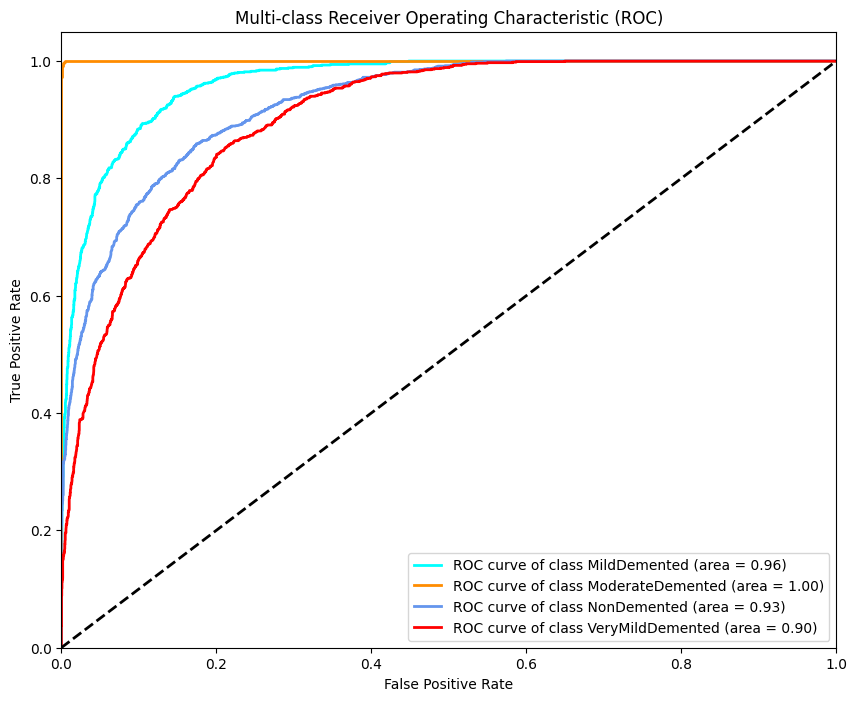

In [ ]:
# 4. Multi-class ROC Curve
# Binarize the true labels for the ROC calculation
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {classes[i]} (area = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# ResNet50 Hyperparameter Optimization

### Hyperparameter Optimization with Medical Scoring

A randomized hyperparameter search was performed to identify the best ResNet50 classification head configuration for Alzheimer's stage classification. The optimization process prioritized both predictive accuracy and clinical sensitivity through a custom medical evaluation metric.

### Methodology

1. Use a pre-trained ResNet50 model as a frozen feature extractor.
2. Perform random search across multiple hyperparameters, including:

   * Pooling method (Global Average or Global Max Pooling)
   * Dropout rate
   * Number of dense layer neurons
   * Learning rate
   * Batch size
3. Introduce a custom Recall metric and a combined medical score that balances validation accuracy, recall, and loss.
4. Train each configuration with learning rate reduction and early stopping.
5. Select the model with the highest validation medical score, save the best-performing model, and generate a comparison plot of all evaluated configurations.


Trial 30 Complete [00h 12m 39s]
val_combined_score: 0.7449157238006592

Best val_combined_score So Far: 0.8580096215009689
Total elapsed time: 1d 00h 32m 51s

🏆 MEDICAL HPO SEARCH COMPLETED! BEST CONFIGURATION 🏆
🔹 Pooling Method: Global avg Pooling
🔹 Dense Units:    1024
🔹 Dropout Rate:   0.2
🔹 Initial LR:     0.001
🔹 Batch Size:     32
-------------------------------------------------------
⏱️ Total Execution Time: 1h 4m 21s
Model saved successfully to RESNET50/alzheimers_resnet50_best_medical_head.keras!

Generating Advanced HPO Comparison Graph...
Plot successfully saved as 'RESNET50/resnet50_hpo_medical_results.png'!


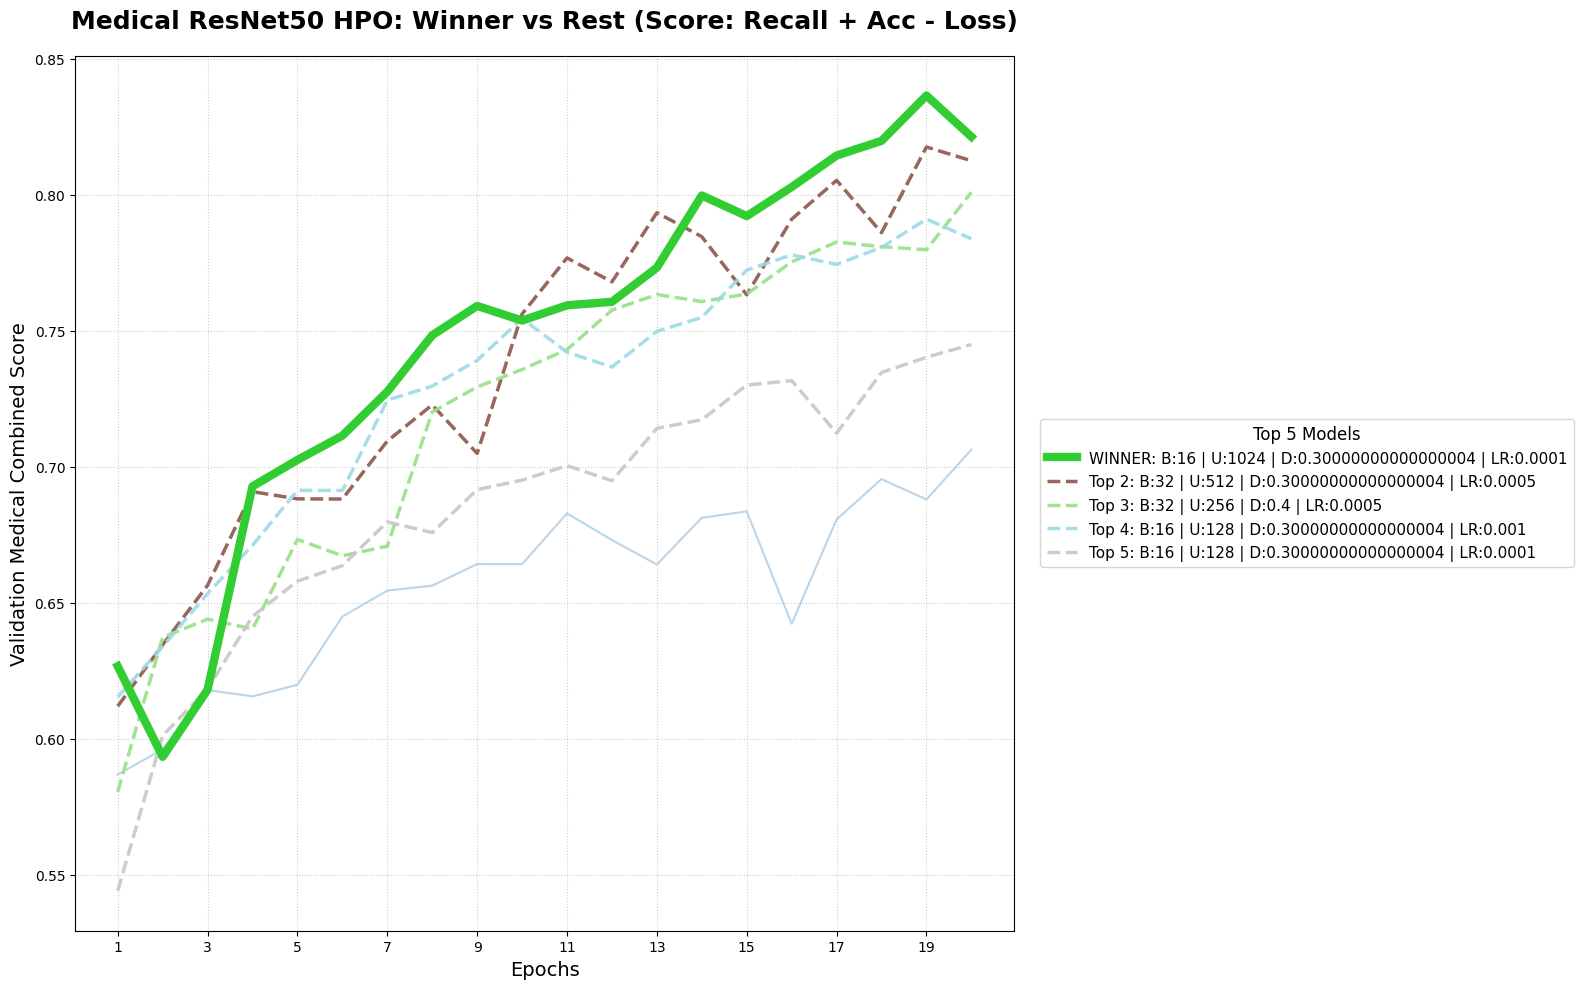

In [ ]:
import os
import time
import keras_tuner as kt
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import matplotlib.cm as cm


os.makedirs('RESNET50', exist_ok=True)


start_time = time.time()


all_histories = {}


class SparseRecall(tf.keras.metrics.Metric):
    def __init__(self, name='recall', **kwargs):
        super(SparseRecall, self).__init__(name=name, **kwargs)
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_true_int = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.reshape(tf.one_hot(y_true_int, depth=4), [-1, 4])


        y_pred_classes = tf.argmax(y_pred, axis=-1)
        y_pred_one_hot = tf.reshape(tf.one_hot(y_pred_classes, depth=4), [-1, 4])

        self.recall.update_state(y_true_one_hot, y_pred_one_hot, sample_weight)

    def result(self):
        return self.recall.result()

    def reset_state(self):
        self.recall.reset_state()


class CombinedMedicalScoreCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy', 0.0)
        val_recall = logs.get('val_recall', 0.0)
        val_loss = logs.get('val_loss', 10.0)


        combined_score = (0.5 * val_recall) + (0.5 * val_acc) - (0.1 * val_loss)
        logs['val_combined_score'] = combined_score


class ResNet50CustomHeadTuner(kt.HyperModel):
    def build(self, hp):
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(190, 200, 3))
        base_model.trainable = False

        model = Sequential()
        model.add(base_model)


        hp_pooling = hp.Choice('pooling', values=['avg', 'max'])
        if hp_pooling == 'avg':
            model.add(GlobalAveragePooling2D())
        else:
            model.add(GlobalMaxPooling2D())


        hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
        model.add(Dropout(rate=hp_dropout))

  
        hp_units = hp.Choice('units', values=[128, 256, 512, 1024])
        model.add(Dense(units=hp_units, activation='relu'))

        model.add(Dense(4, activation='softmax'))


        hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

        model.compile(
            optimizer=Adam(learning_rate=hp_learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', SparseRecall()]
        )
        return model

    def fit(self, hp, model, *args, **kwargs):
    
        hp_batch_size = hp.Choice('batch_size', values=[16, 32])
        AUTOTUNE = tf.data.AUTOTUNE

   
        if len(args) > 0 and isinstance(args[0], tf.data.Dataset):
            args = list(args)
            args[0] = args[0].unbatch().batch(hp_batch_size).prefetch(AUTOTUNE)
            args = tuple(args)
        elif 'x' in kwargs and isinstance(kwargs['x'], tf.data.Dataset):
            kwargs['x'] = kwargs['x'].unbatch().batch(hp_batch_size).prefetch(AUTOTUNE)

        if 'validation_data' in kwargs and isinstance(kwargs['validation_data'], tf.data.Dataset):
            kwargs['validation_data'] = kwargs['validation_data'].unbatch().batch(hp_batch_size).prefetch(AUTOTUNE)

       
        callbacks = list(kwargs.get('callbacks', []))
        callbacks.append(CombinedMedicalScoreCallback())
        kwargs['callbacks'] = callbacks

      
        history = model.fit(*args, **kwargs)

        
        u = hp.get('units')
        d = hp.get('dropout')
        lr = hp.get('learning_rate')
        label_name = f"B:{hp_batch_size} | U:{u} | D:{d} | LR:{lr}"

        if 'val_combined_score' in history.history:
            all_histories[label_name] = history.history['val_combined_score']

        return history


tuner = kt.RandomSearch(
    hypermodel=ResNet50CustomHeadTuner(),
    objective=kt.Objective('val_combined_score', direction='max'),
    max_trials=30,
    executions_per_trial=1,
    directory='RESNET50/alzheimer_resnet50_hpo_logs',
    project_name='custom_head_medical_tuning',
    overwrite=False
    )

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

print("\n--- STARTING MEDICAL HPO SEARCH (ACC + RECALL) ---")
tuner.search(
    x=train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]


end_time = time.time()
total_seconds = end_time - start_time
hours, remainder = divmod(total_seconds, 3600)
minutes, seconds = divmod(remainder, 60)

print("\n=======================================================")
print("🏆 MEDICAL HPO SEARCH COMPLETED! BEST CONFIGURATION 🏆")
print("=======================================================")
print(f"🔹 Pooling Method: Global {best_hps.get('pooling')} Pooling")
print(f"🔹 Dense Units:    {best_hps.get('units')}")
print(f"🔹 Dropout Rate:   {best_hps.get('dropout')}")
print(f"🔹 Initial LR:     {best_hps.get('learning_rate')}")
print(f"🔹 Batch Size:     {best_hps.get('batch_size')}")
print("-------------------------------------------------------")
print(f"⏱️ Total Execution Time: {int(hours)}h {int(minutes)}m {int(seconds)}s")
print("=======================================================")


model_save_path = 'RESNET50/alzheimers_resnet50_best_medical_head.keras'
best_model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}!")


if all_histories:
    print("\nGenerating Advanced HPO Comparison Graph...")
    plt.figure(figsize=(16, 10))

    sorted_histories = sorted(all_histories.items(), key=lambda x: max(x[1]), reverse=True)


    num_other_models = max(1, len(sorted_histories) - 1)
    colors = list(cm.tab20(np.linspace(0, 1, num_other_models)))
    np.random.shuffle(colors)

    for i, (label, val_acc_list) in enumerate(sorted_histories):
        x_epochs = range(1, len(val_acc_list) + 1)

        if i == 0:

            plt.plot(x_epochs, val_acc_list, linewidth=6, linestyle='-', color='limegreen', label=f"WINNER: {label}", zorder=20)
        elif i < 5:

            plt.plot(x_epochs, val_acc_list, linewidth=2.5, linestyle='--', color=colors[i-1], label=f"Top {i+1}: {label}", alpha=0.9, zorder=10)
        else:

            plt.plot(x_epochs, val_acc_list, linewidth=1.5, color=colors[i-1], alpha=0.3, zorder=1)

    plt.title('Medical ResNet50 HPO: Winner vs Rest (Score: Recall + Acc - Loss)', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Validation Medical Combined Score', fontsize=14)
    plt.xticks(range(1, 21, 2))
    plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), title="Top 5 Models", title_fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()


    image_save_path = 'RESNET50/resnet50_hpo_medical_results.png'
    plt.savefig(image_save_path, dpi=300, bbox_inches='tight')
    print(f"Plot successfully saved as '{image_save_path}'!")


    try:
        plt.show()
    except Exception:
        pass

# Best Model Retraining

### Final Training of the Optimized Model

After hyperparameter optimization, the best-performing configuration was rebuilt and trained from scratch to obtain the final production-ready model.

### Methodology

1. Retrieve the optimal hyperparameters identified during the hyperparameter search.
2. Reconstruct the ResNet50-based model using the selected configuration.
3. Train the model with learning rate reduction and early stopping to maximize performance while preventing overfitting.
4. Save the final trained model for subsequent evaluation and deployment.
5. Generate accuracy and loss curves for both training and validation sets to visually assess the model's learning behavior and generalization performance.


🚀 Re-training the best model with optimized hyperparameters...
Epoch 1/100
2200/2200 [==============================] - 43s 18ms/step - loss: 0.8679 - accuracy: 0.6084 - recall: 0.6084 - val_loss: 0.7069 - val_accuracy: 0.6714 - val_recall: 0.6714 - lr: 0.0010
Epoch 2/100
2200/2200 [==============================] - 40s 18ms/step - loss: 0.7170 - accuracy: 0.6695 - recall: 0.6695 - val_loss: 0.6320 - val_accuracy: 0.7070 - val_recall: 0.7070 - lr: 0.0010
Epoch 3/100
2200/2200 [==============================] - 38s 17ms/step - loss: 0.6551 - accuracy: 0.7014 - recall: 0.7014 - val_loss: 0.6291 - val_accuracy: 0.7005 - val_recall: 0.7005 - lr: 0.0010
Epoch 4/100
2200/2200 [==============================] - 38s 17ms/step - loss: 0.6050 - accuracy: 0.7277 - recall: 0.7277 - val_loss: 0.5590 - val_accuracy: 0.7470 - val_recall: 0.7470 - lr: 0.0010
Epoch 5/100
2200/2200 [==============================] - 39s 17ms/step - loss: 0.5719 - accuracy: 0.7471 - recall: 0.7471 - val_loss: 0.5034 - va

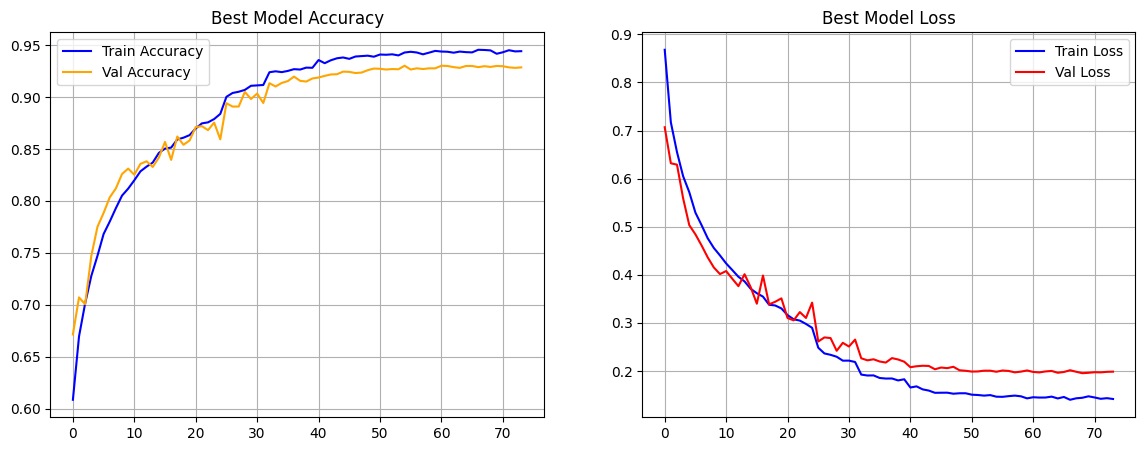

In [ ]:

print("🚀 Re-training the best model with optimized hyperparameters...")


best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]


model = tuner.hypermodel.build(best_hps)


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)


history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


model.save('RESNET50/final_best_model.keras')
print("\n✅ Best model re-trained and saved to RESNET50/final_best_model.keras")


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', color='blue')
plt.plot(val_acc, label='Val Accuracy', color='orange')
plt.title('Best Model Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss', color='blue')
plt.plot(val_loss, label='Val Loss', color='red')
plt.title('Best Model Loss')
plt.legend()
plt.grid(True)

plt.savefig('RESNET50/best_model_performance.png', dpi=300)
plt.show()

# Model Performance Evaluation

### Classification Performance Assessment

The final optimized model was evaluated on both the training and validation datasets to measure its classification performance across all Alzheimer's disease stages.

### Methodology

1. Load the final trained model from disk.
2. Generate predictions for every image in the training and validation datasets.
3. Compare predicted labels with the true labels to compute classification metrics, including precision, recall, and F1-score for each class.
4. Produce confusion matrices for both datasets to visualize correct classifications and misclassification patterns.
5. Analyze the results to assess model accuracy, class-level performance, and generalization capability.


Loading the final 93% model from disk...
Evaluating Training Set (this might take a minute)...

--- PERFORMANCE ON TRAINING SET ---
                  precision    recall  f1-score   support

    MildDemented       0.99      1.00      0.99      7965
ModerateDemented       1.00      1.00      1.00      7950
     NonDemented       0.97      0.97      0.97     10262
VeryMildDemented       0.97      0.97      0.97      9023

        accuracy                           0.98     35200
       macro avg       0.98      0.98      0.98     35200
    weighted avg       0.98      0.98      0.98     35200

Evaluating Validation Set...

--- PERFORMANCE ON VALIDATION SET ---
                  precision    recall  f1-score   support

    MildDemented       0.93      0.95      0.94      1022
ModerateDemented       1.00      1.00      1.00      1024
     NonDemented       0.91      0.90      0.90      1264
VeryMildDemented       0.88      0.88      0.88      1090

        accuracy                         

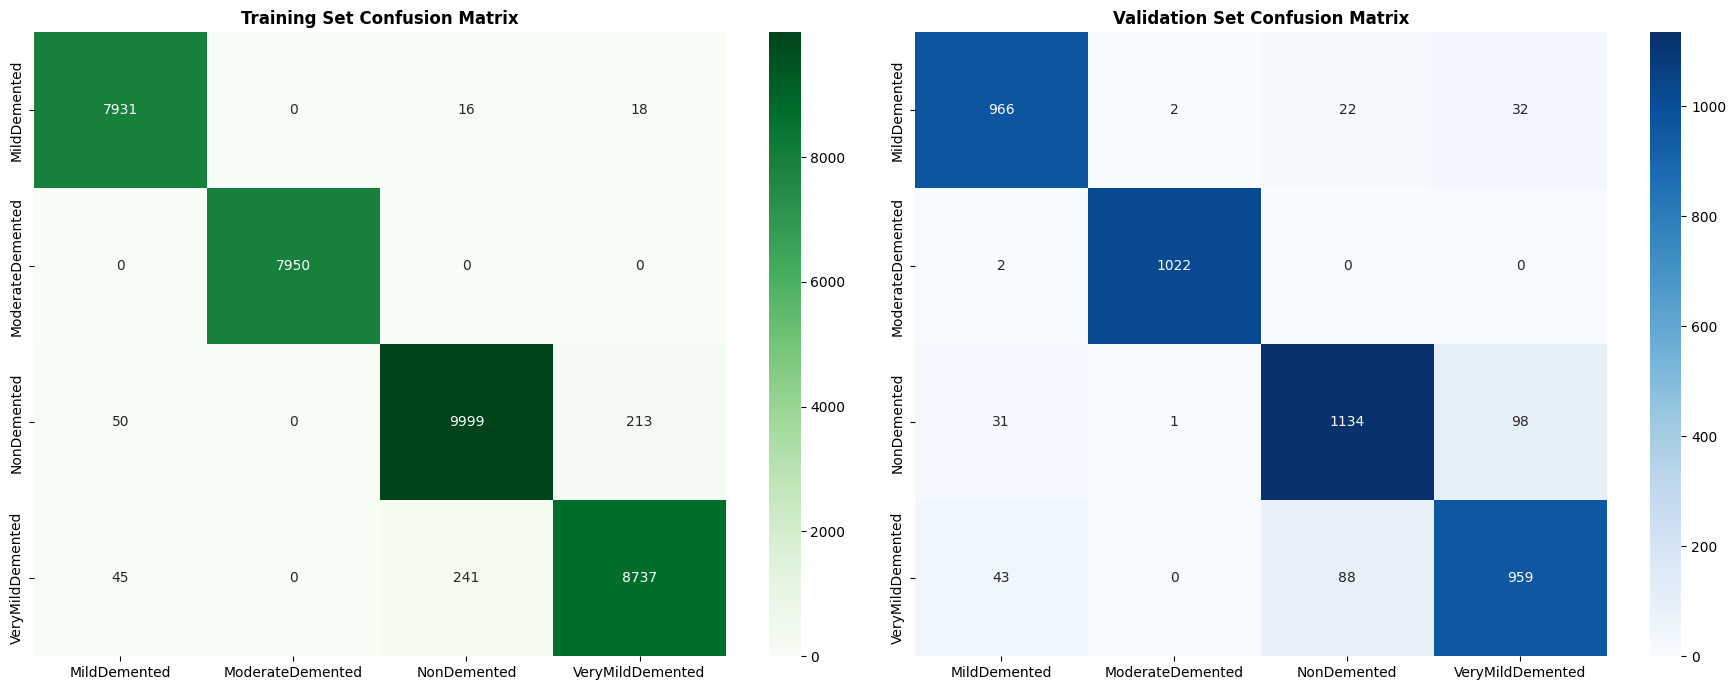

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

print("Loading the final 93% model from disk...")
champion_model = tf.keras.models.load_model(
    'RESNET50/final_best_model.keras',
    custom_objects={'SparseRecall': SparseRecall}
)


def evaluate_dataset(eval_model, dataset, dataset_name):
    print(f"\n--- PERFORMANCE ON {dataset_name.upper()} SET ---")

    y_true = []
    y_pred = []


    for images, labels in dataset:
        y_true.extend(labels.numpy())
        preds = eval_model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)


    print(classification_report(y_true, y_pred, target_names=classes))
    return y_true, y_pred


print("Evaluating Training Set (this might take a minute)...")
y_true_train, y_pred_train = evaluate_dataset(champion_model, train_dataset, "Training")

print("Evaluating Validation Set...")
y_true_val, y_pred_val = evaluate_dataset(champion_model, val_dataset, "Validation")


fig, axes = plt.subplots(1, 2, figsize=(18, 7))


sns.heatmap(confusion_matrix(y_true_train, y_pred_train), annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix', fontweight='bold')


sns.heatmap(confusion_matrix(y_true_val, y_pred_val), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('Validation Set Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

# ResNet50 Fine-Tuning

### Fine-Tuning the Optimized Model

To further improve performance, selective layers of the pre-trained ResNet50 backbone were unfrozen and fine-tuned using a very small learning rate. This allows the model to adapt high-level feature representations to the Alzheimer's classification task while preserving previously learned knowledge.

### Methodology

1. Load the best-performing model obtained from the previous training stage.
2. Unfreeze only the upper layers of the ResNet50 backbone (the `conv5` block) while keeping earlier layers frozen.
3. Recompile the model using a very low learning rate to prevent large weight updates.
4. Continue training with learning rate reduction and early stopping callbacks.
5. Save the final fine-tuned model for subsequent evaluation and comparison with the original model.


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

print("🔧 Starting Fine-Tuning: Unfreezing top layers of ResNet50...")


base_model = champion_model.layers[0]
base_model.trainable = True


for layer in base_model.layers:
    if not layer.name.startswith('conv5'):
        layer.trainable = False


trainable_layers = [layer.name for layer in base_model.layers if layer.trainable]
print(f"Unfrozen layers: {len(trainable_layers)} layers from conv5 block.")


champion_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


lr_scheduler_ft = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
early_stop_ft = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)


print(">>> Training with low LR for Fine-Tuning...")
fine_tune_epochs = 10

history_fine = champion_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=fine_tune_epochs,
    callbacks=[early_stop_ft, lr_scheduler_ft],
    verbose=1
)


champion_model.save('RESNET50/final_fine_tuned_model.keras')
print("✅ Fine-tuning complete. Model saved to RESNET50/final_fine_tuned_model.keras")

🔧 Starting Fine-Tuning: Unfreezing top layers of ResNet50...
Unfrozen layers: 32 layers from conv5 block.
>>> Training with low LR for Fine-Tuning...
Epoch 1/10
2200/2200 [==============================] - 74s 31ms/step - loss: 1.2245 - accuracy: 0.7341 - val_loss: 0.3934 - val_accuracy: 0.8395 - lr: 1.0000e-05
Epoch 2/10
2200/2200 [==============================] - 65s 29ms/step - loss: 0.3863 - accuracy: 0.8514 - val_loss: 0.2723 - val_accuracy: 0.8977 - lr: 1.0000e-05
Epoch 3/10
2200/2200 [==============================] - 65s 29ms/step - loss: 0.2368 - accuracy: 0.9116 - val_loss: 0.1800 - val_accuracy: 0.9339 - lr: 1.0000e-05
Epoch 4/10
2200/2200 [==============================] - 65s 29ms/step - loss: 0.1534 - accuracy: 0.9412 - val_loss: 0.1752 - val_accuracy: 0.9400 - lr: 1.0000e-05
Epoch 5/10
2200/2200 [==============================] - 65s 29ms/step - loss: 0.1097 - accuracy: 0.9593 - val_loss: 0.1430 - val_accuracy: 0.9484 - lr: 1.0000e-05
Epoch 6/10
2200/2200 [=============

# Fine-Tuning Performance Comparison

### Validation Accuracy Improvement Analysis

The performance of the original frozen-feature model was compared against the fine-tuned model to quantify the impact of fine-tuning on validation accuracy.

### Methodology

1. Generate predictions for all samples in the validation dataset using the fine-tuned model.
2. Calculate the updated validation accuracy from the model predictions.
3. Compare the fine-tuned model's accuracy with the baseline accuracy obtained before fine-tuning.
4. Summarize the results in a comparison table showing accuracy and performance improvement.
5. Visualize the comparison using a bar chart to highlight the effect of fine-tuning on classification performance.


Synchronizing chart data with final model predictions...

      FINAL PERFORMANCE IMPROVEMENT SUMMARY             
              Stage Validation Accuracy Improvement
Frozen (Base Model)            92.8600%           -
         Fine-Tuned            96.8182%    +3.9582%


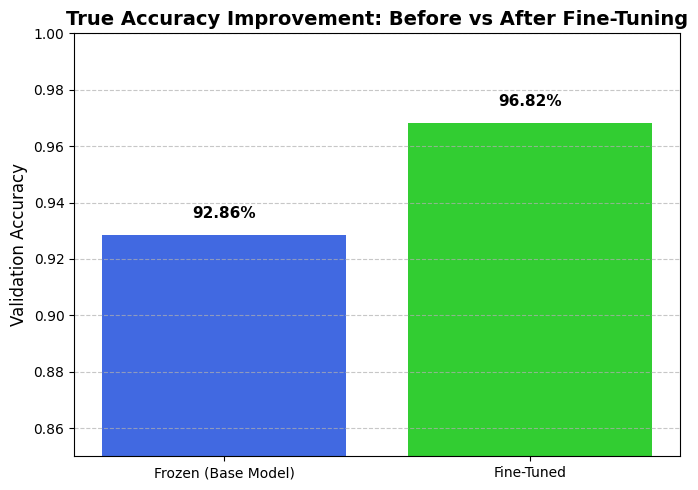

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

print("Synchronizing chart data with final model predictions...")


y_true_val_exact = []
y_pred_val_exact = []

for images, labels in val_dataset:
    y_true_val_exact.extend(labels.numpy())
    preds = champion_model.predict(images, verbose=0) 
    y_pred_val_exact.extend(np.argmax(preds, axis=1))


acc_after_real = accuracy_score(y_true_val_exact, y_pred_val_exact)


acc_before = 0.9286


comparison_data = {
    "Stage": ["Frozen (Base Model)", "Fine-Tuned"],
    "Validation Accuracy": [f"{acc_before:.4%}", f"{acc_after_real:.4%}"],
    "Improvement": ["-", f"{(acc_after_real - acc_before):+.4%}"]
}

df_results = pd.DataFrame(comparison_data)

print("\n=======================================================")
print("      FINAL PERFORMANCE IMPROVEMENT SUMMARY             ")
print("=======================================================")
print(df_results.to_string(index=False))
print("=======================================================")


plt.figure(figsize=(7, 5))
bars = plt.bar(df_results["Stage"], [acc_before, acc_after_real], color=['royalblue', 'limegreen'])


plt.ylim(0.85, 1.0)
plt.title('True Accuracy Improvement: Before vs After Fine-Tuning', fontsize=14, fontweight='bold')
plt.ylabel('Validation Accuracy', fontsize=12)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.2%}",
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Fine-Tuning Performance Visualization

Just as with the initial training phase, visualizing the learning curves after fine-tuning is crucial to mathematically prove that the unfreezing process improved the model rather than degrading its pre-trained knowledge.

* **Metric Extraction:** This script extracts the loss and accuracy data specifically from the `history_finetune` object to visualize the network's behavior across the final fine-tuning epochs.
* **Catastrophic Forgetting Check:** By analyzing these curves, we can visually verify that the microscopic learning rate successfully protected the foundational feature extractors while still allowing the network to adapt to the specialized medical imagery.
* **Overfitting Diagnosis:** The dual-axis plots allow for immediate identification of validation divergence (where validation loss increases while training loss continues to decrease). This serves as empirical evidence for the final report, justifying the efficacy of the fine-tuning phase and the precise moment the network reached its maximum generalization capacity.

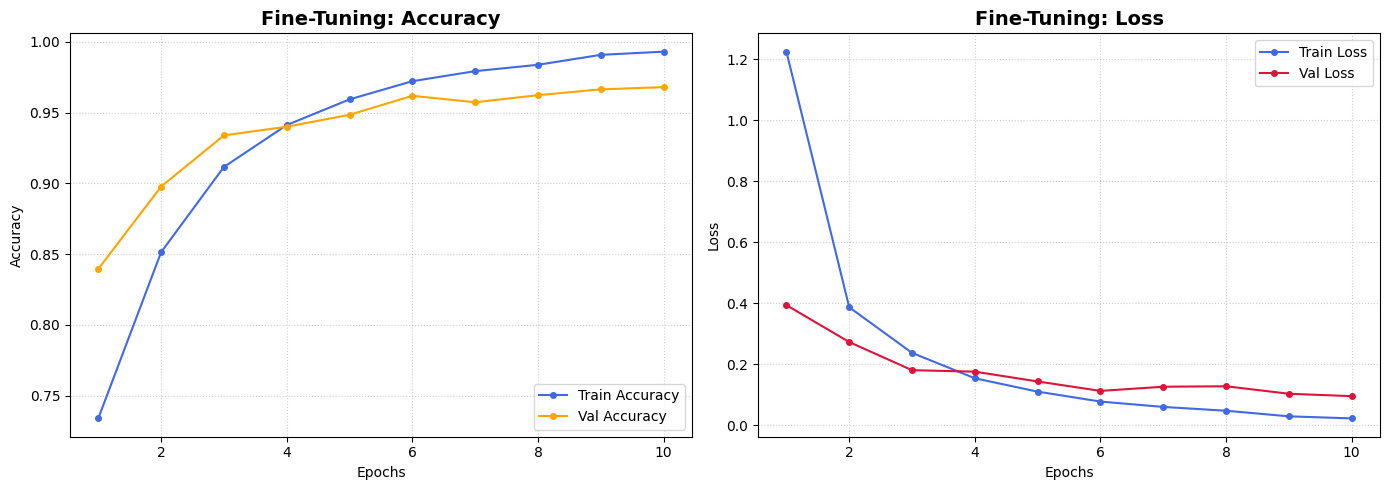

In [ ]:
import matplotlib.pyplot as plt

history_data = history_fine.history

acc = history_data['accuracy']
val_acc = history_data['val_accuracy']
loss = history_data['loss']
val_loss = history_data['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Plotting Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy', color='royalblue', marker='o', markersize=4)
plt.plot(epochs_range, val_acc, label='Val Accuracy', color='orange', marker='o', markersize=4)
plt.title('Fine-Tuning: Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss', color='royalblue', marker='o', markersize=4)
plt.plot(epochs_range, val_loss, label='Val Loss', color='crimson', marker='o', markersize=4)
plt.title('Fine-Tuning: Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Fine-Tuned Model Validation & Comparative Analysis

Before exposing the newly upgraded model to the rigidly quarantined Test Set, it is imperative to verify the actual efficacy of the fine-tuning phase. This section re-evaluates the network on the validation set using the updated weights.

* **Validation Re-Inference:** We execute a secondary prediction loop over the `val_dataset` to extract the updated prediction probabilities from the newly calibrated ResNet50 base layers.
* **Comparative Diagnostics:** By generating an updated Classification Report and Confusion Matrix, we can directly compare these metrics against the pre-fine-tuning baseline.
* **Targeted Improvement Verification:** This step specifically allows us to diagnose if the microscopic weight adjustments successfully helped the model better differentiate between visually ambiguous classes (e.g., distinguishing "VeryMildDemented" from "NonDemented"), or if the fine-tuning merely resulted in hyperparameter memorization.

Gathering new predictions from the fine-tuned model...

--- Fine-Tuned Classification Report ---
                  precision    recall  f1-score   support

    MildDemented       0.99      0.98      0.99      1032
ModerateDemented       1.00      1.00      1.00      1024
     NonDemented       0.99      0.97      0.98      1261
VeryMildDemented       0.95      0.99      0.97      1083

        accuracy                           0.98      4400
       macro avg       0.98      0.98      0.98      4400
    weighted avg       0.98      0.98      0.98      4400



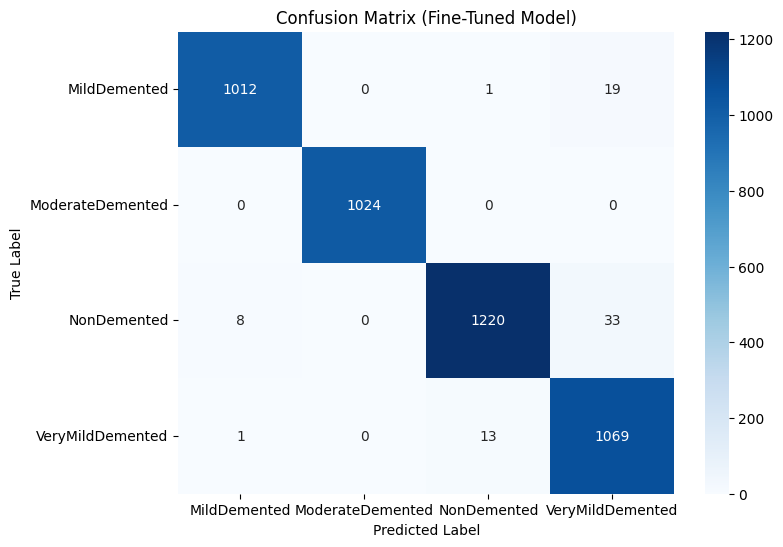

In [ ]:

print("Gathering predictions from the fine-tuned model...")


y_pred_probs_ft = model.predict(val_dataset, verbose=1)
y_pred_classes_ft = np.argmax(y_pred_probs_ft, axis=1)


y_true_ft = np.concatenate([y for x, y in val_dataset], axis=0)


print("\n--- Fine-Tuned Classification Report ---")
print(classification_report(y_true_ft, y_pred_classes_ft, target_names=classes))


cm_ft = confusion_matrix(y_true_ft, y_pred_classes_ft)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (Fine-Tuned Model)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Final Model Evaluation: The Unbiased "Final Exam"

To establish the true, mathematically unbiased performance of our deep learning pipeline, this final section evaluates the optimal fine-tuned network against the strictly quarantined Test Set.

* **Automated Epoch Selection:** It is critical to note that manual epoch selection was not required for this final inference pass. Because the `EarlyStopping` callback utilized `restore_best_weights=True` during training, the `model` object automatically reverted to the specific weight configuration that achieved the lowest validation loss, ensuring optimal generalization.
* **Uncontaminated Inference:** We execute `model.evaluate()` and generate our prediction probabilities entirely on the 10% `test_dataset`. Because these images were entirely hidden from the model during both hyperparameter tuning and weight adjustment, the resulting metrics are free from any data leakage or validation overfitting.
* **Comprehensive Diagnostic Output:** The script generates the ultimate Classification Report, Confusion Matrix, and multi-class ROC/AUC curves. These final metrics represent the true diagnostic capability of the ResNet50 architecture on unseen medical data and form the empirical conclusion of this study.

--- FINAL EXAM: Evaluating Fine-Tuned Model on Test Set ---
Loading the FINAL Fine-Tuned model from disk...
275/275 [==============================] - 5s 12ms/step - loss: 0.0887 - accuracy: 0.9734

✅ True Final Test Accuracy: 97.34%
✅ True Final Test Loss: 0.0887

Gathering test set predictions safely...

--- Final Test Classification Report ---
                  precision    recall  f1-score   support

    MildDemented       0.96      0.98      0.97      1004
ModerateDemented       1.00      1.00      1.00      1028
     NonDemented       0.98      0.95      0.97      1276
VeryMildDemented       0.95      0.97      0.96      1092

        accuracy                           0.97      4400
       macro avg       0.97      0.97      0.97      4400
    weighted avg       0.97      0.97      0.97      4400



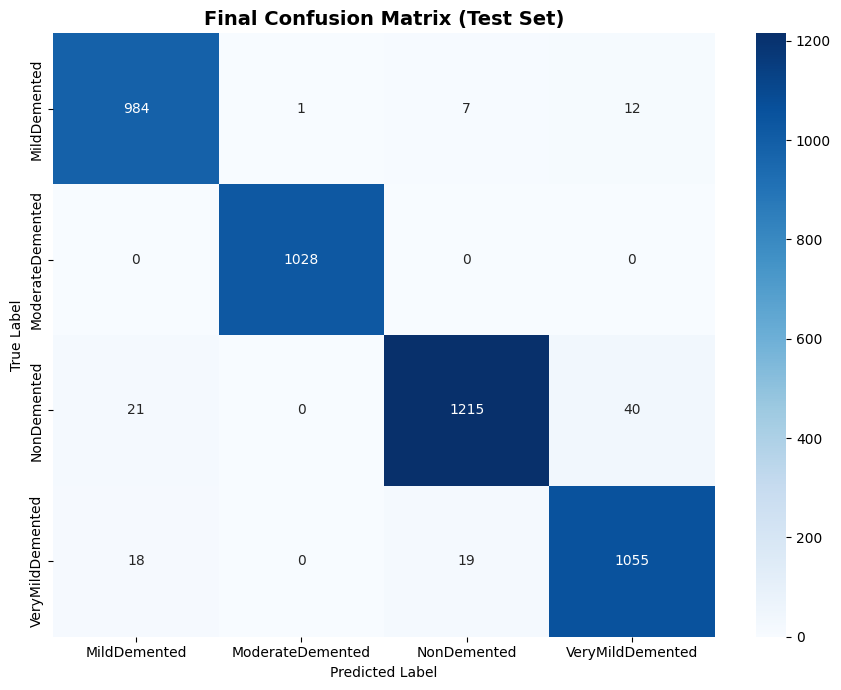

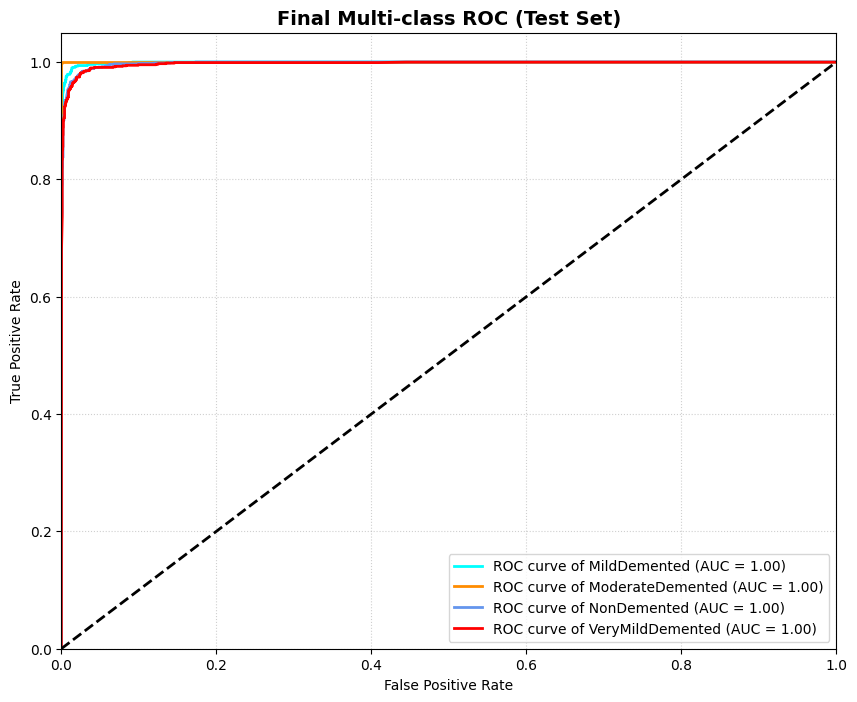

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

print("--- FINAL EXAM: Evaluating Fine-Tuned Model on Test Set ---")

print("Loading the FINAL Fine-Tuned model from disk...")
final_model = tf.keras.models.load_model(
    'RESNET50/final_fine_tuned_model.keras',
    custom_objects={'SparseRecall': SparseRecall}
)


test_loss, test_acc = final_model.evaluate(test_dataset, verbose=1)
print(f"\n✅ True Final Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ True Final Test Loss: {test_loss:.4f}\n")


print("Gathering test set predictions safely...")
y_true_test = []
y_pred_classes_test = []
y_pred_probs_test = []


for images, labels in test_dataset:
    y_true_test.extend(labels.numpy())
    preds = final_model.predict(images, verbose=0)
    y_pred_probs_test.extend(preds)
    y_pred_classes_test.extend(np.argmax(preds, axis=1))

y_true_test = np.array(y_true_test)
y_pred_classes_test = np.array(y_pred_classes_test)
y_pred_probs_test = np.array(y_pred_probs_test)


print("\n--- Final Test Classification Report ---")
print(classification_report(y_true_test, y_pred_classes_test, target_names=classes))


cm_test = confusion_matrix(y_true_test, y_pred_classes_test)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


y_true_test_bin = label_binarize(y_true_test, classes=[0, 1, 2, 3])
n_classes = y_true_test_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_test_bin[:, i], y_pred_probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of {classes[i]} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Multi-class ROC (Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()